# Modélisation : régression logistique (pipeline et validation)

Objectif : construire un modèle de classification binaire pour prédire la souscription (`y`)  
en respectant un cadre prédictif cohérent (prétraitement, validation, métriques adaptées).

In [ ]:

# Importation des bibliothèques nécessaires
import sys
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer

from src.modeles import ColonnesModele, separer_X_y, construire_modele_logistique
from src.evaluation import (
    evaluer_classification_binaire,
    afficher_matrice_confusion,
    afficher_rapport_classification,
    tracer_roc
)

## 1. Chargement des données préparées

J'utilise le fichier exporté à la fin du Notebook 1.

In [4]:
DATA_PATH = ROOT / "data" / "processed" / "bank_clean_step1.parquet"
df = pd.read_parquet(DATA_PATH)

df.shape, df.head()

((41176, 20),
    age        job  marital    education  default housing loan    contact  \
 0   56  housemaid  married     basic.4y       no      no   no  telephone   
 1   57   services  married  high.school  unknown      no   no  telephone   
 2   37   services  married  high.school       no     yes   no  telephone   
 3   40     admin.  married     basic.6y       no      no   no  telephone   
 4   56   services  married  high.school       no      no  yes  telephone   
 
   month day_of_week  campaign  pdays  previous     poutcome  emp_var_rate  \
 0   may         mon         1    999         0  nonexistent           1.1   
 1   may         mon         1    999         0  nonexistent           1.1   
 2   may         mon         1    999         0  nonexistent           1.1   
 3   may         mon         1    999         0  nonexistent           1.1   
 4   may         mon         1    999         0  nonexistent           1.1   
 
    cons_price_idx  cons_conf_idx  euribor3m  nr_emp

## 2. Définition des variables explicatives

Je distingue variables numériques et catégorielles afin de construire un pipeline de prétraitement :
- imputation + standardisation pour les numériques,
- imputation + one-hot encoding pour les catégorielles.

In [5]:
cible = "y"

numeriques = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorielles = df.select_dtypes(include=["object"]).columns.tolist()

if cible in categorielles:
    categorielles.remove(cible)

# Vérification : y doit exister et être binaire
assert cible in df.columns 
assert df[cible].nunique() == 2

colonnes = ColonnesModele(
    cible=cible,
    numeriques=numeriques,
    categorielles=categorielles
)

cible, len(numeriques), numeriques, len(categorielles), categorielles

C:\Users\Etudiant\AppData\Local\Temp\ipykernel_4468\1378093221.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorielles = df.select_dtypes(include=["object"]).columns.tolist()


('y',
 9,
 ['age',
  'campaign',
  'pdays',
  'previous',
  'emp_var_rate',
  'cons_price_idx',
  'cons_conf_idx',
  'euribor3m',
  'nr_employed'],
 10,
 ['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'day_of_week',
  'poutcome'])

## 3. Séparation entraînement / test (stratifiée)

Le dataset étant déséquilibré, on effectue un split stratifié afin de conserver une proportion similaire
de classes dans l'entraînement et le test.

In [ ]:
# Séparation des données en train et test

X, y = separer_X_y(df, colonnes)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% des données pour le test
    random_state=42, # pour la reproductibilité
    stratify=y # pour conserver la même proportion de classes dans les deux ensembles
)

y_train.value_counts(normalize=True).round(4), y_test.value_counts(normalize=True).round(4)

(y
 no     0.8873
 yes    0.1127
 Name: proportion, dtype: float64,
 y
 no     0.8873
 yes    0.1127
 Name: proportion, dtype: float64)

## 4. Modèle de base : régression logistique (L2)

On entraîne un modèle logistique avec régularisation L2.
Les métriques suivies sont : précision, rappel, F1-score et ROC-AUC.

In [ ]:
# Construction du modèle de base
modele_base = construire_modele_logistique(
    colonnes=colonnes,
    penalty="l2", # régularisation L2
    C=1.0, # inverse de la force de régularisation (plus C est petit, plus la régularisation est forte)
    class_weight=None # pas de pondération des classes (équilibrage)
)

modele_base

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [9]:
# entraînement du modèle de base
modele_base.fit(X_train, y_train)

y_pred = modele_base.predict(X_test) # prédiction des classes
y_proba = modele_base.predict_proba(X_test)[:, 1] # prédiction des probabilités de la classe positive (yes)

metriques = evaluer_classification_binaire(y_test, y_pred, y_proba=y_proba, pos_label="yes")
metriques

c:\Users\Etudiant\Documents\cours Algo pour l'apprentissage\Projet_Scoring_bank-marketing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


{'accuracy': 0.8983,
 'precision': 0.651,
 'recall': 0.2091,
 'f1': 0.3165,
 'roc_auc': 0.8004}

## 5. Variante : prise en compte du déséquilibre (class_weight='balanced')

Je compare une logistique pondérée afin d'augmenter l'importance de la classe minoritaire.
L’objectif est d’améliorer le rappel (recall) de la classe positive.

In [ ]:
# Construction du modèle pondéré
modele_pondere = construire_modele_logistique(
    colonnes=colonnes,
    penalty="l2", # régularisation L2
    C=1.0, # inverse de la force de régularisation (plus C est petit, plus la régularisation est forte)
    class_weight="balanced" # pondération automatique des classes en fonction de leur fréquence (équilibrage)
)

modele_pondere.fit(X_train, y_train)

y_pred_w = modele_pondere.predict(X_test) # prédiction des classes
y_proba_w = modele_pondere.predict_proba(X_test)[:, 1] # prédiction des probabilités de la classe positive (yes)

metriques_w = evaluer_classification_binaire(y_test, y_pred_w, y_proba=y_proba_w, pos_label="yes")
metriques_w

c:\Users\Etudiant\Documents\cours Algo pour l'apprentissage\Projet_Scoring_bank-marketing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


{'accuracy': 0.8303,
 'precision': 0.3591,
 'recall': 0.6455,
 'f1': 0.4615,
 'roc_auc': 0.8002}

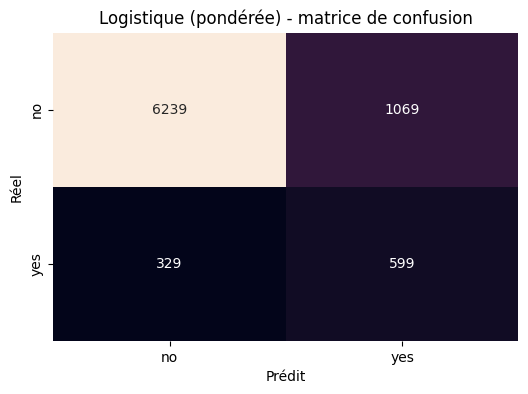

              precision    recall  f1-score   support

          no       0.95      0.85      0.90      7308
         yes       0.36      0.65      0.46       928

    accuracy                           0.83      8236
   macro avg       0.65      0.75      0.68      8236
weighted avg       0.88      0.83      0.85      8236



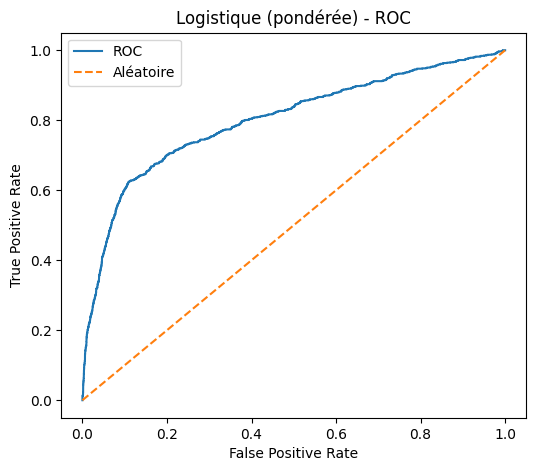

In [26]:
# Affichage des résultats du modèle pondéré
afficher_matrice_confusion(y_test, y_pred_w, labels=("no", "yes"), titre="Logistique (pondérée) - matrice de confusion")
afficher_rapport_classification(y_test, y_pred_w)
tracer_roc(y_test, y_proba_w, pos_label="yes", titre="Logistique (pondérée) - ROC")

## 6. Validation croisée (Stratified K-Fold)

J'estime la performance moyenne par validation croisée stratifiée,
avec une métrique principale adaptée : ROC-AUC.

In [ ]:
# Comparaison des deux modèles (base et pondéré) en validation croisée, en utilisant plusieurs métriques d'évaluation :
cv = StratifiedKFold(n_splits=5,  # nombre de folds
                     shuffle=True, # pour mélanger les données avant de les diviser en folds
                     random_state=42) # pour la reproductibilité

scoring = {
    "roc_auc": "roc_auc", 
    "f1_pos": make_scorer(lambda yt, yp: evaluer_classification_binaire(yt, yp, pos_label="yes")["f1"]),
    "recall_pos": make_scorer(lambda yt, yp: evaluer_classification_binaire(yt, yp, pos_label="yes")["recall"]),
    "precision_pos": make_scorer(lambda yt, yp: evaluer_classification_binaire(yt, yp, pos_label="yes")["precision"])
}

# Note : je peux aussi faire du cross_val_predict pour obtenir les prédictions de chaque fold et calculer les métriques à la main, 
# mais cross_validate est plus rapide car il utilise les fonctions optimisées de scikit-learn
scores_base = cross_validate(modele_base, X, y, cv=cv, scoring=scoring, n_jobs=-1)
scores_pond = cross_validate(modele_pondere, X, y, cv=cv, scoring=scoring, n_jobs=-1)

# Résumé des résultats de la validation croisée
def resume_cv(scores, nom):
    out = {k: float(np.mean(v)) for k, v in scores.items() if k.startswith("test_")}
    out = {k.replace("test_", ""): round(v, 4) for k, v in out.items()}
    print(nom, out)

resume_cv(scores_base, "Logistique (base)")
resume_cv(scores_pond, "Logistique (pondérée)")

Logistique (base) {'roc_auc': 0.7913, 'f1_pos': 0.3407, 'recall_pos': 0.2298, 'precision_pos': 0.6594}
Logistique (pondérée) {'roc_auc': 0.7928, 'f1_pos': 0.4504, 'recall_pos': 0.6286, 'precision_pos': 0.3509}


### interprétation des coefficients de la Régression Logistique

In [13]:

# récupérer le préprocesseur du pipeline
preprocessor = modele_base.named_steps["preprocessor"]

# récupérer les noms des variables transformées
feature_names = preprocessor.get_feature_names_out()

In [ ]:
# Détermination des coefficients du modèle de base
import pandas as pd

coefficients = modele_base.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "variable": feature_names,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values("coefficient", ascending=False)

coef_df.head(10)

,variable,coefficient
49,cat__month_mar,1.243210
5,num__cons_price_idx,1.139315
29,cat__education_illiterate,0.471020
8,num__nr_employed,0.453392
46,cat__month_dec,0.327497
7,num__euribor3m,0.296041
14,cat__job_retired,0.244143
45,cat__month_aug,0.243377
61,cat__poutcome_success,0.186024
17,cat__job_student,0.184732


In [ ]:
# Calcul des odds ratios (rapport de cotes) pour interpréter l'importance des variables
odds_ratio = pd.Series(np.exp(coefficients), index=feature_names)
odds_ratio.sort_values(ascending=False).head(10)

cat__month_mar               3.466725
num__cons_price_idx          3.124626
cat__education_illiterate    1.601626
num__nr_employed             1.573640
cat__month_dec               1.387491
num__euribor3m               1.344525
cat__job_retired             1.276527
cat__month_aug               1.275549
cat__poutcome_success        1.204451
cat__job_student             1.202895
dtype: float64

In [23]:

# Nettoyage des noms de variables pour une meilleure lisibilité
coef_df["variable"] = (
    coef_df["variable"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

<Axes: title={'center': 'Variables influençant la probabilité de souscription'}, ylabel='variable'>

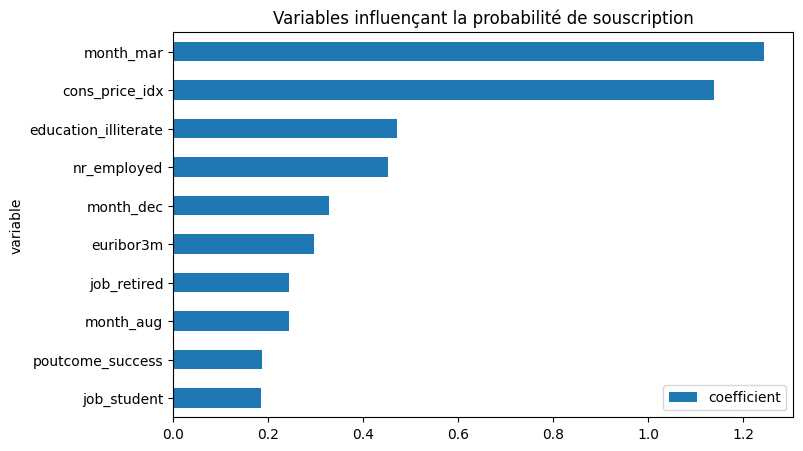

In [24]:
top_coef = coef_df.sort_values("coefficient").tail(10)

top_coef.plot(
    x="variable",
    y="coefficient",
    kind="barh",
    figsize=(8,5),
    title="Variables influençant la probabilité de souscription"
)

## 7. Conclusion

Dans ce notebook, j’ai :
- construit un pipeline de prétraitement (numériques/catégorielles),
- entraîné une régression logistique (base) et une variante pondérée,
- évalué les modèles avec des métriques adaptées (F1, recall, ROC-AUC),
- estimé la performance moyenne par validation croisée stratifiée.

Le Notebook 3 sera consacré :
- à la comparaison avec un modèle non linéaire (ex. Random Forest),
- à une recherche d’hyperparamètres,
- à une sélection d’un modèle final et à son évaluation consolidée.